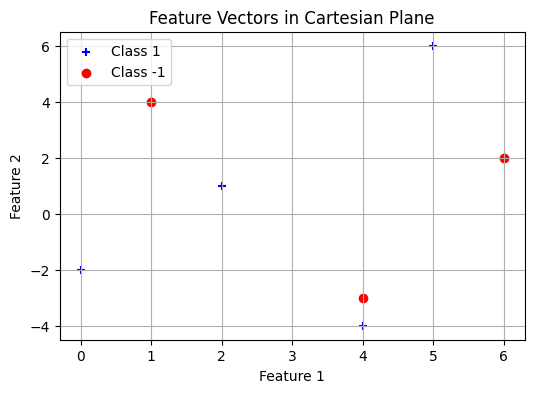

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Data matrix X
X = np.array([[0, -2],
              [1, 4],
              [2, 1],
              [4, -4],
              [4, -3],
              [5, 6],
              [6, 2]])

y = np.array([1, -1, 1, 1, -1, 1, -1])

plt.figure(figsize=(6, 4))

# Plot the points
for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='b', marker='+', label='Class 1' if i == 0 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], color='r', marker='o', label='Class -1' if i == 1 else "")

# Labeling the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')


plt.legend()

plt.title('Feature Vectors in Cartesian Plane')

plt.grid(True)
plt.show()


X_bias:  [[ 1.  0. -2.]
 [ 1.  1.  4.]
 [ 1.  2.  1.]
 [ 1.  4. -4.]
 [ 1.  4. -3.]
 [ 1.  5.  6.]
 [ 1.  6.  2.]]
matrix:  [[ 1.  0. -2.  1.]
 [ 1.  1.  4. -1.]
 [ 1.  2.  1.  1.]
 [ 1.  4. -4.  1.]
 [ 1.  4. -3. -1.]
 [ 1.  5.  6.  1.]
 [ 1.  6.  2. -1.]]


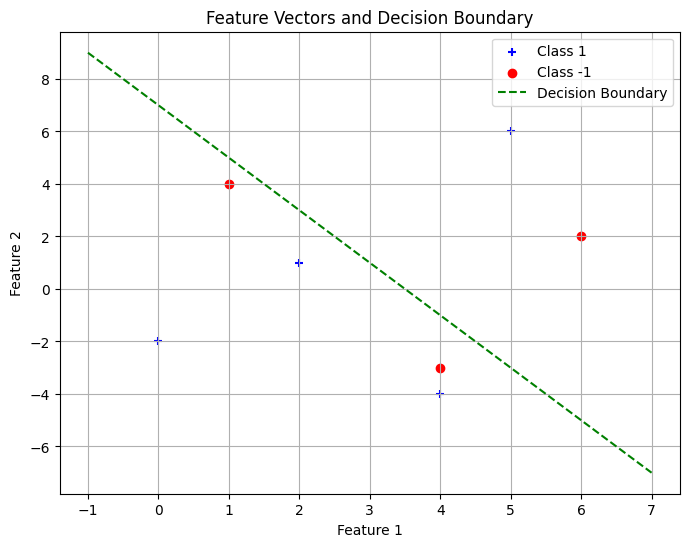

In [39]:

# Weight vector (w0) for the decision boundary
w0 = np.array([-7, 2, 1])
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
print('X_bias: ', X_bias )
matrix = np.hstack([np.ones((X.shape[0], 1)), X, y.reshape(-1, 1)])
print('matrix: ', matrix )

plt.figure(figsize=(8, 6))

# Plot the points
for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], color='b', marker='+', label='Class 1' if i == 0 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], color='r', marker='o', label='Class -1' if i == 1 else "")


x1_values = np.linspace(-1, 7, 100)
#print('x1_values', x1_values)
x2_values = 7 - 2 * x1_values 
#print('x2_values', x2_values)

plt.plot(x1_values, x2_values, color='g', label='Decision Boundary', linestyle='--')

# Labeling the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend()
plt.title('Feature Vectors and Decision Boundary')

# Show the plot
plt.grid(True)
plt.show()


X_bias:  [[ 1.  0. -2.]
 [ 1.  1.  4.]
 [ 1.  2.  1.]
 [ 1.  4. -4.]
 [ 1.  4. -3.]
 [ 1.  5.  6.]
 [ 1.  6.  2.]]
Weights at each epoch:
      w0    w1   w2
0   -5.0  -2.0  5.0
1   -3.0 -10.0 -3.0
2   -1.0  -8.0  5.0
3    3.0  -6.0  9.0
4    5.0  -6.0  5.0
5    5.0 -14.0  9.0
6    7.0 -14.0  5.0
7   11.0 -12.0  9.0
8   13.0 -12.0  5.0
9   13.0 -12.0  5.0
10  13.0 -12.0  5.0
11  13.0 -12.0  5.0
12  13.0 -12.0  5.0
13  13.0 -12.0  5.0
14  13.0 -12.0  5.0


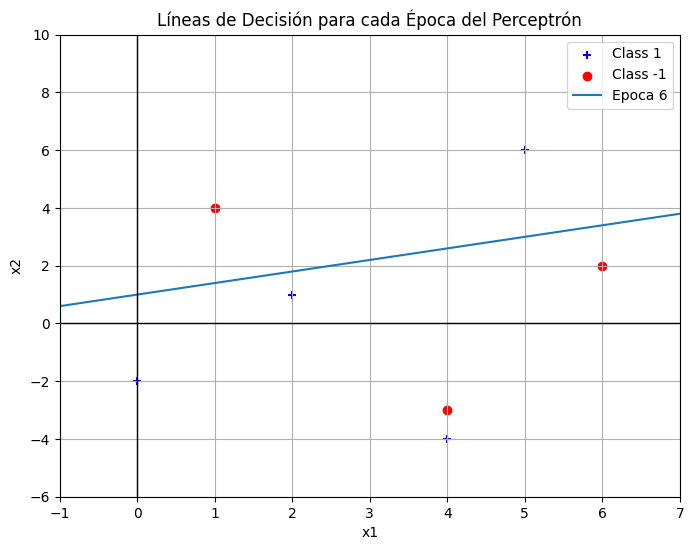

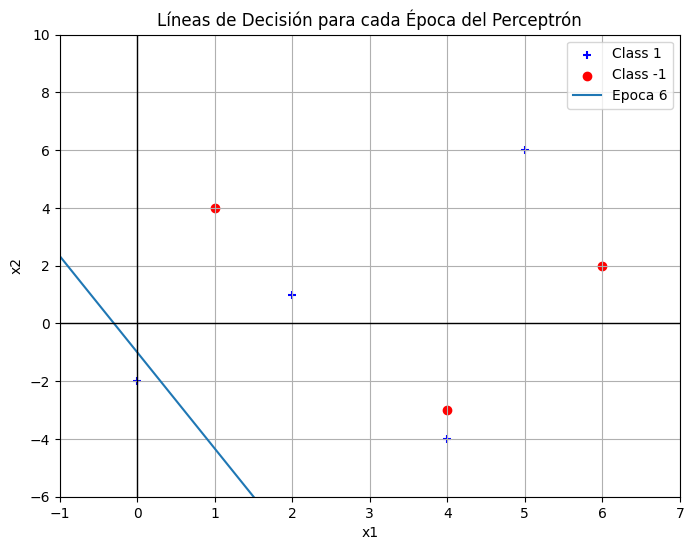

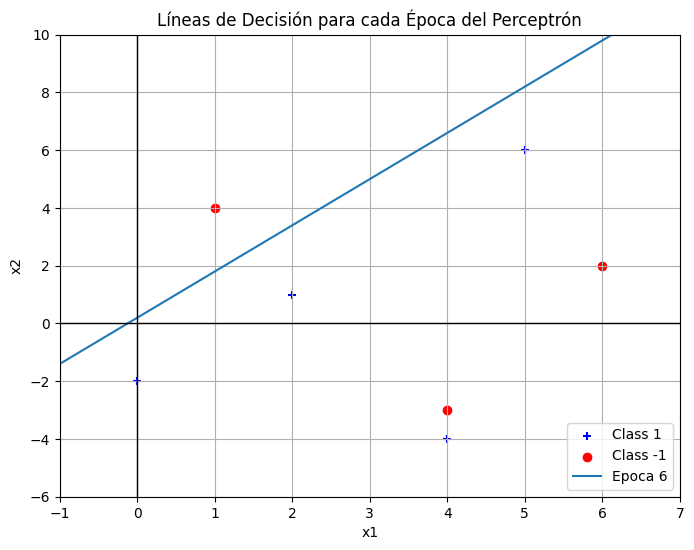

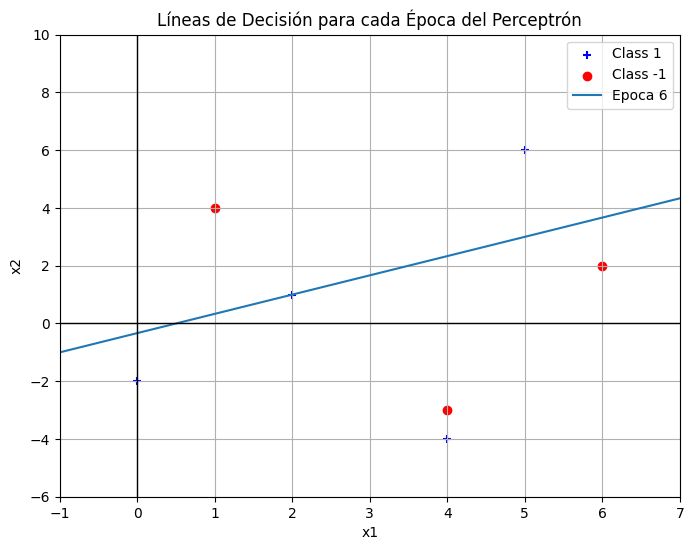

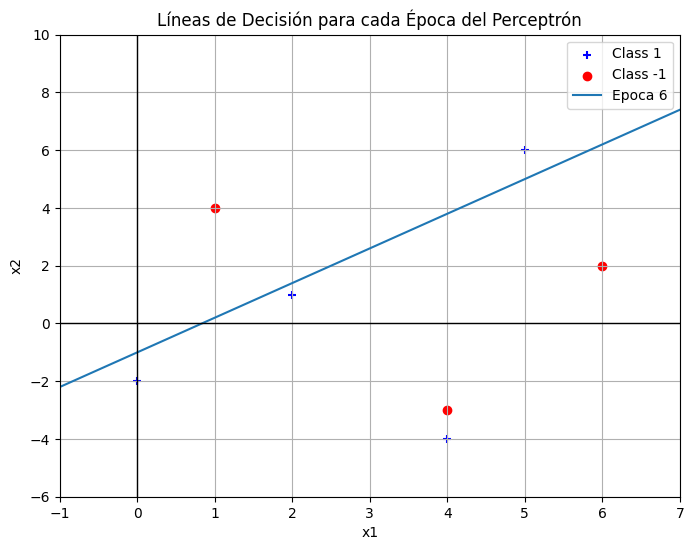

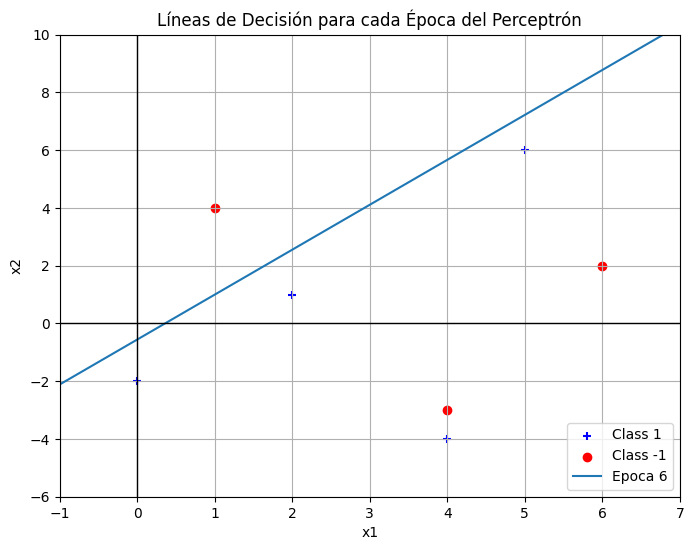

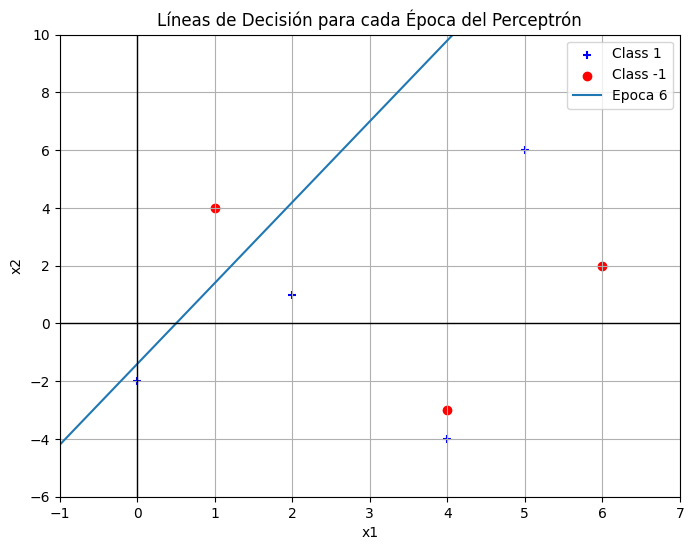

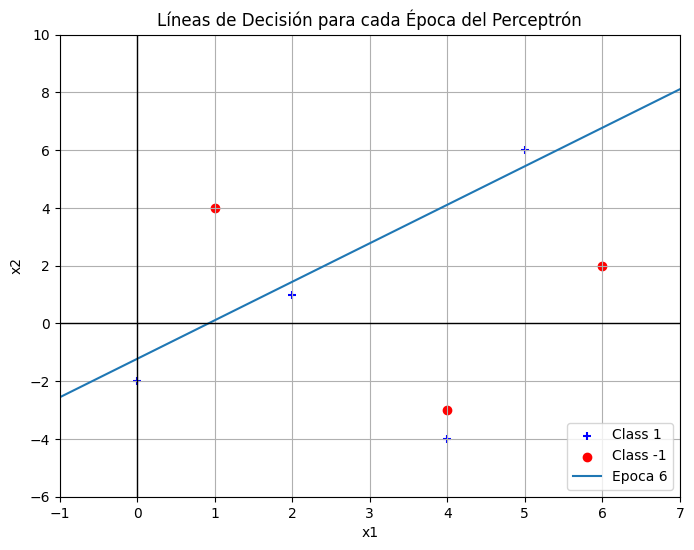

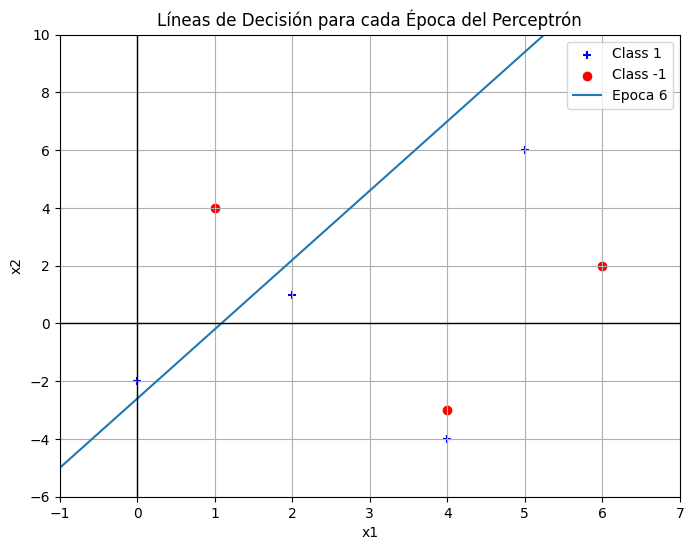

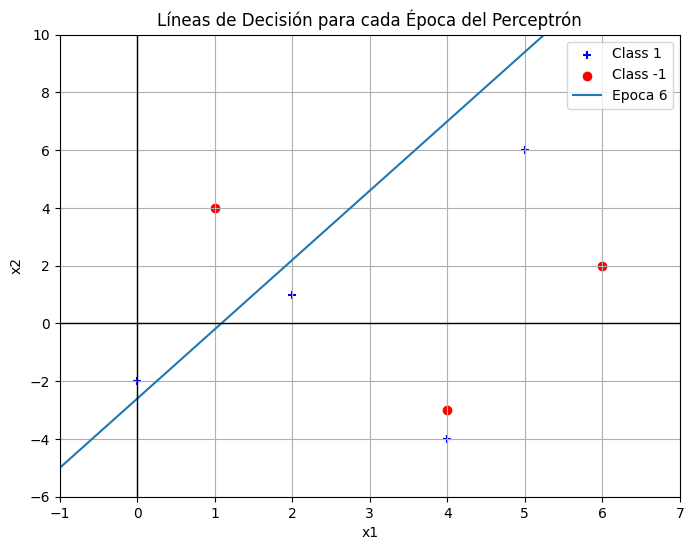

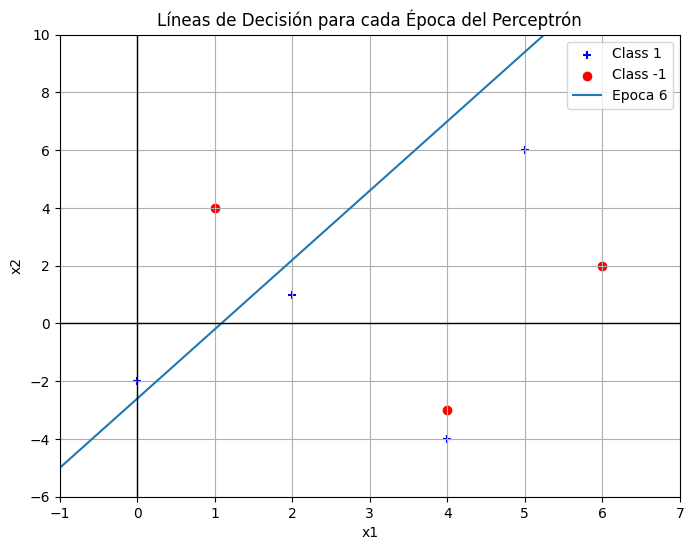

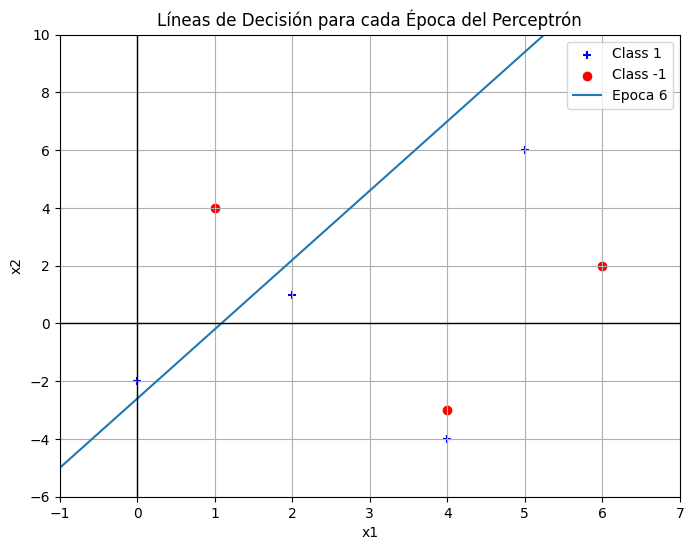

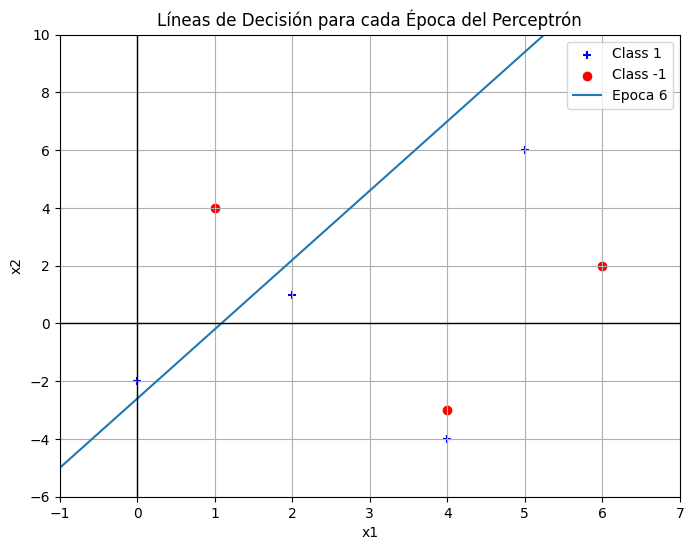

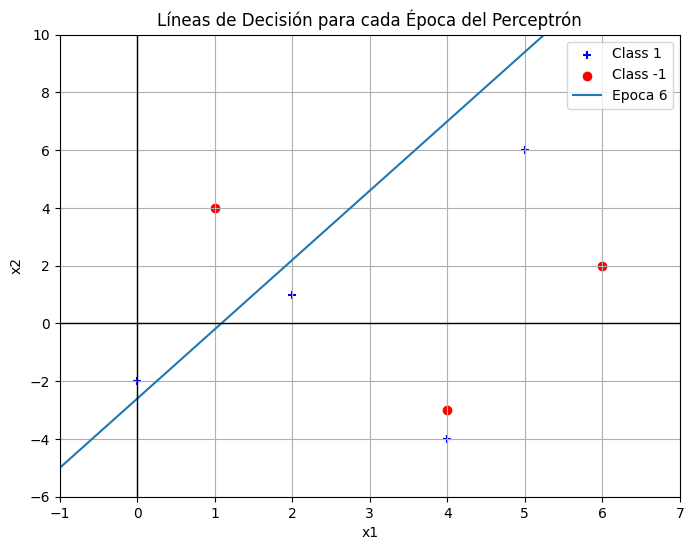

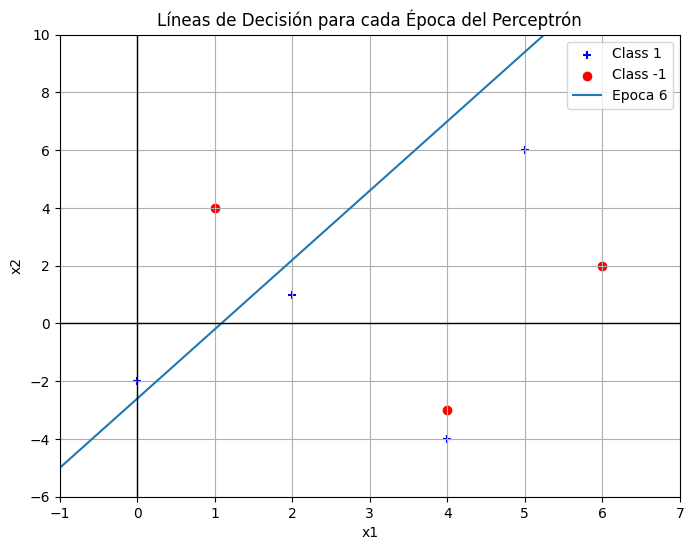

In [41]:
import numpy as np
import pandas as pd


# Add the bias term (1) to each feature vector in X
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
print('X_bias: ', X_bias )
# Initialize the weight vector (including the bias weight)
w = np.array([-7, 2, 1], dtype=float)

# Learning rate
eta = 1

# Number of epochs (iterations)
epochs = 15

# To store weights at each epoch
weights_history = []

# Gradient Descent Perceptron Algorithm
for epoch in range(epochs):
    for i in range(len(X_bias)):
        # Compute the dot product (activation)
        activation = np.dot(w, X_bias[i])
        
        # Prediction: sign of the activation
        prediction = 1 if activation >= 0 else -1
        
        # Update weights if prediction is wrong
        if prediction != y[i]:
            w = w + eta * (y[i] - prediction) * X_bias[i]
    
    # Store weights after each epoch
    weights_history.append(w.copy())

# Convert weights history into a DataFrame for a nice table format
weights_df = pd.DataFrame(weights_history, columns=['w0', 'w1', 'w2'])



# Print the table of weights
print("Weights at each epoch:")
print(weights_df)





# Ploting for each epoch
x1_values = np.linspace(-1, 7, 100) 
for i, w_epoch in enumerate(weights_history):
    # x2 = -w0/w2 - (w1/w2) * x1
    w0, w1, w2 = w_epoch
    x2_values = -(w0 / w2) - (w1 / w2) * x1_values 

    plt.figure(figsize=(8, 6))
    for i in range(len(X)):
        if y[i] == 1:
            plt.scatter(X[i, 0], X[i, 1], color='b', marker='+', label='Class 1' if i == 0 else "")
        else:
            plt.scatter(X[i, 0], X[i, 1], color='r', marker='o', label='Class -1' if i == 1 else "")
    
    plt.plot(x1_values, x2_values, label=f'Epoca {i}')

    plt.xlim(-1, 7)
    plt.ylim(-6, 10)
    plt.axhline(0, color='black',linewidth=1)
    plt.axvline(0, color='black',linewidth=1)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('Líneas de Decisión para cada Época del Perceptrón')
    plt.legend()
    plt.grid(True)

    plt.show()
